# Checkpoint 5 — Statistical Computing & Machine Learning

**Dataset:** WINES (`wines.csv`)  
**Linguagem:** Python

Este notebook foi desenvolvido da seguinte forma:
- **Parte 1:** análise exploratória de duas variáveis quantitativas, distribuição de frequências, gráficos, estatística descritiva e análise probabilística;
- **Parte 2:** agrupamento dos vinhos com **K-means**, pré-processamento, método Elbow, Silhueta e interpretação dos grupos.

> **Integrantes do grupo:** 
- Brian Barreto Brasil - rm570384
- Davi Oliveira da Silva - rm569108
- João Pedro Morangoni - rm570073
- João Vitor Xavier de Carvalho - rm570633
- Victor Deggerone Gomes - rm569518


## 1. Bibliotecas

As bibliotecas abaixo serão utilizadas para manipulação dos dados, visualização, estatística e Machine Learning.

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

## 2. Carregamento do dataset

**Fonte indicada no enunciado:** Kaggle e GitHub. 

In [11]:
USAR_ARQUIVO_LOCAL = True
ARQUIVO_LOCAL = "wine-clustering.csv"

URL_DATASET = "https://raw.githubusercontent.com/tijptjik/9408623/master/wine.csv"

if USAR_ARQUIVO_LOCAL:
    df = pd.read_csv(ARQUIVO_LOCAL)
else:
    try:
        df = pd.read_csv(URL_DATASET)
    except Exception as erro:
        print("Não foi possível carregar pela URL.")
        print("Erro:", erro)
        print("Use USAR_ARQUIVO_LOCAL = True e coloque wines.csv na pasta do notebook.")
        raise

print("Dimensões:", df.shape)
display(df.head())


Dimensões: (178, 13)


,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


## 3. Conhecendo os dados

Antes das análises, verificamos as colunas, tipos de dados, valores ausentes e estatísticas básicas. Essa etapa também ajuda a identificar a variável de classe, caso exista, que não deve ser usada como feature no agrupamento.

In [12]:
print("Informações do dataset:")
display(df.info())

print("\nValores ausentes por coluna:")
display(df.isnull().sum())

print("\nEstatísticas iniciais:")
display(df.describe())


Informações do dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Alcohol               178 non-null    float64
 1   Malic_Acid            178 non-null    float64
 2   Ash                   178 non-null    float64
 3   Ash_Alcanity          178 non-null    float64
 4   Magnesium             178 non-null    int64  
 5   Total_Phenols         178 non-null    float64
 6   Flavanoids            178 non-null    float64
 7   Nonflavanoid_Phenols  178 non-null    float64
 8   Proanthocyanins       178 non-null    float64
 9   Color_Intensity       178 non-null    float64
 10  Hue                   178 non-null    float64
 11  OD280                 178 non-null    float64
 12  Proline               178 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 18.2 KB


None


Valores ausentes por coluna:


Alcohol                 0
Malic_Acid              0
Ash                     0
Ash_Alcanity            0
Magnesium               0
Total_Phenols           0
Flavanoids              0
Nonflavanoid_Phenols    0
Proanthocyanins         0
Color_Intensity         0
Hue                     0
OD280                   0
Proline                 0
dtype: int64


Estatísticas iniciais:


,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


# PARTE 1 — Statistical Computing with Python

O enunciado pede a seleção de **duas variáveis quantitativas** e, para cada uma, uma tabela de distribuição de frequências e gráfico, análise descritiva e análise probabilística.

Neste trabalho serão utilizadas:
- **Alcohol:** teor alcoólico;
- **Malic acid:** acidez málica.


In [13]:
# Identificação das colunas quantitativas
print(df.dtypes)

# Conferência dos nomes disponíveis
print("\nColunas:")
print(df.columns.tolist())


Alcohol                 float64
Malic_Acid              float64
Ash                     float64
Ash_Alcanity            float64
Magnesium                 int64
Total_Phenols           float64
Flavanoids              float64
Nonflavanoid_Phenols    float64
Proanthocyanins         float64
Color_Intensity         float64
Hue                     float64
OD280                   float64
Proline                   int64
dtype: object

Colunas:
['Alcohol', 'Malic_Acid', 'Ash', 'Ash_Alcanity', 'Magnesium', 'Total_Phenols', 'Flavanoids', 'Nonflavanoid_Phenols', 'Proanthocyanins', 'Color_Intensity', 'Hue', 'OD280', 'Proline']


## 4. Variável 1 — Alcohol

### 4.1 Tabela de distribuição de frequências e gráfico

A tabela divide os valores de teor alcoólico em intervalos. Isso permite observar como os vinhos estão distribuídos em diferentes faixas de álcool.

,Intervalo,Frequência,Frequência relativa (%)
0,"(11.025, 11.663]",10,5.62
1,"(11.663, 12.297]",31,17.42
2,"(12.297, 12.93]",43,24.16
3,"(12.93, 13.563]",43,24.16
4,"(13.563, 14.197]",38,21.35
5,"(14.197, 14.83]",13,7.30


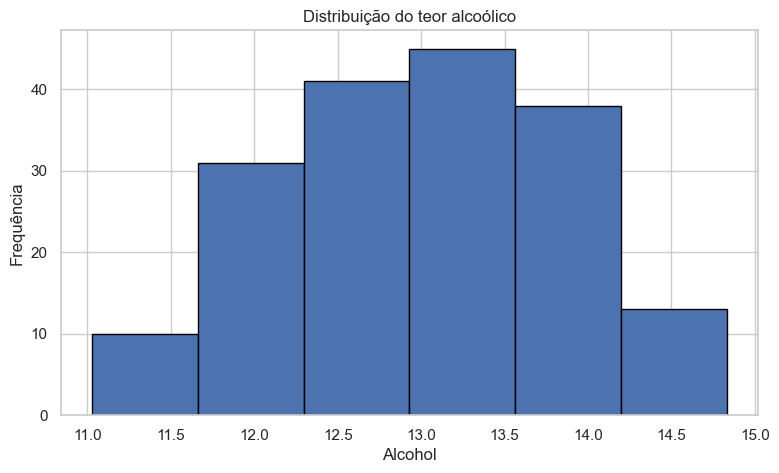

In [14]:
variavel1 = "Alcohol"

# Criamos intervalos automaticamente usando 6 classes.
freq_alcohol = pd.cut(df[variavel1], bins=6, include_lowest=True).value_counts().sort_index()

tabela_alcohol = pd.DataFrame({
    "Intervalo": freq_alcohol.index.astype(str),
    "Frequência": freq_alcohol.values,
    "Frequência relativa (%)": (freq_alcohol.values / len(df) * 100).round(2)
})

display(tabela_alcohol)

# Gráfico de distribuição
plt.figure(figsize=(9, 5))
plt.hist(df[variavel1], bins=6, edgecolor="black")
plt.title("Distribuição do teor alcoólico")
plt.xlabel("Alcohol")
plt.ylabel("Frequência")
plt.show()

# Interpretação:
# O histograma mostra em quais faixas de teor alcoólico existe maior concentração de vinhos.
# A classe com maior frequência representa a faixa de álcool mais comum no conjunto analisado.


### 4.2 Análise descritiva — Alcohol

Serão calculadas medidas de tendência central (média, mediana e moda), medidas de dispersão (variância, desvio padrão, amplitude e coeficiente de variação) e quartis.

In [15]:
media = df[variavel1].mean()
mediana = df[variavel1].median()
moda = df[variavel1].mode().tolist()

variancia = df[variavel1].var()
desvio_padrao = df[variavel1].std()
amplitude = df[variavel1].max() - df[variavel1].min()
coef_variacao = desvio_padrao / media * 100

q1 = df[variavel1].quantile(0.25)
q2 = df[variavel1].quantile(0.50)
q3 = df[variavel1].quantile(0.75)
iqr = q3 - q1

estat_alcohol = pd.DataFrame({
    "Medida": [
        "Média", "Mediana", "Moda", "Variância", "Desvio padrão",
        "Amplitude", "Coeficiente de variação (%)",
        "Q1", "Q2 (mediana)", "Q3", "Amplitude interquartil (IQR)"
    ],
    "Valor": [
        media, mediana, str(moda), variancia, desvio_padrao,
        amplitude, coef_variacao, q1, q2, q3, iqr
    ]
})

display(estat_alcohol)

# Interpretação:
# Média e mediana permitem comparar o centro da distribuição.
# O desvio padrão indica o quanto os valores se afastam, em média, da média.
# O IQR mostra a dispersão dos 50% centrais dos dados.


,Medida,Valor
0,Média,13.000618
1,Mediana,13.05
2,Moda,"[12.37, 13.05]"
3,Variância,0.659062
4,Desvio padrão,0.811827
5,Amplitude,3.8
6,Coeficiente de variação (%),6.244523
7,Q1,12.3625
8,Q2 (mediana),13.05
9,Q3,13.6775


### 4.3 Análise probabilística — Alcohol

Para uma análise probabilística simples, vamos aproximar a variável por uma **distribuição normal** usando sua média e desvio padrão. Em seguida, calcularemos duas probabilidades.


In [16]:
mu_alcohol = df[variavel1].mean()
sigma_alcohol = df[variavel1].std()

# Probabilidade 1: P(Alcohol <= média)
p1 = stats.norm.cdf(mu_alcohol, loc=mu_alcohol, scale=sigma_alcohol)

# Probabilidade 2: P(Alcohol > Q3)
p2 = 1 - stats.norm.cdf(q3, loc=mu_alcohol, scale=sigma_alcohol)

print(f"P(Alcohol <= média) ≈ {p1:.4f} ({p1*100:.2f}%)")
print(f"P(Alcohol > Q3) ≈ {p2:.4f} ({p2*100:.2f}%)")

# Interpretação:
# Pela distribuição normal ajustada, a probabilidade de um valor estar abaixo ou igual
# à média é aproximadamente 50%.
# A segunda probabilidade estima a chance de encontrar um teor alcoólico acima do terceiro quartil
# considerando a aproximação normal.


P(Alcohol <= média) ≈ 0.5000 (50.00%)
P(Alcohol > Q3) ≈ 0.2022 (20.22%)


## 5. Variável 2 — Malic acid

### 5.1 Tabela de distribuição de frequências e gráfico

A mesma metodologia será aplicada à variável `Malic_Acid`, permitindo comparar sua distribuição.

,Intervalo,Frequência,Frequência relativa (%)
0,"(0.734, 1.583]",43,24.16
1,"(1.583, 2.427]",71,39.89
2,"(2.427, 3.27]",25,14.04
3,"(3.27, 4.113]",24,13.48
4,"(4.113, 4.957]",10,5.62
5,"(4.957, 5.8]",5,2.81


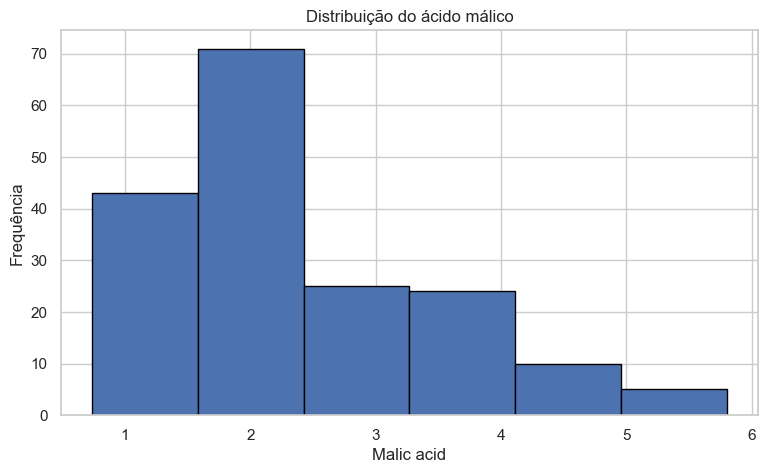

In [19]:
variavel2 = "Malic_Acid"

freq_malic = pd.cut(df[variavel2], bins=6, include_lowest=True).value_counts().sort_index()

tabela_malic = pd.DataFrame({
    "Intervalo": freq_malic.index.astype(str),
    "Frequência": freq_malic.values,
    "Frequência relativa (%)": (freq_malic.values / len(df) * 100).round(2)
})

display(tabela_malic)

plt.figure(figsize=(9, 5))
plt.hist(df[variavel2], bins=6, edgecolor="black")
plt.title("Distribuição do ácido málico")
plt.xlabel("Malic acid")
plt.ylabel("Frequência")
plt.show()

# Interpretação:
# O histograma permite identificar as faixas de acidez málica mais frequentes.


### 5.2 Análise descritiva — Malic acid

In [20]:
media2 = df[variavel2].mean()
mediana2 = df[variavel2].median()
moda2 = df[variavel2].mode().tolist()

variancia2 = df[variavel2].var()
desvio_padrao2 = df[variavel2].std()
amplitude2 = df[variavel2].max() - df[variavel2].min()
coef_variacao2 = desvio_padrao2 / media2 * 100

q1_2 = df[variavel2].quantile(0.25)
q2_2 = df[variavel2].quantile(0.50)
q3_2 = df[variavel2].quantile(0.75)
iqr2 = q3_2 - q1_2

estat_malic = pd.DataFrame({
    "Medida": [
        "Média", "Mediana", "Moda", "Variância", "Desvio padrão",
        "Amplitude", "Coeficiente de variação (%)",
        "Q1", "Q2 (mediana)", "Q3", "Amplitude interquartil (IQR)"
    ],
    "Valor": [
        media2, mediana2, str(moda2), variancia2, desvio_padrao2,
        amplitude2, coef_variacao2, q1_2, q2_2, q3_2, iqr2
    ]
})

display(estat_malic)

# Interpretação:
# A média e a mediana mostram a tendência central da acidez.
# O desvio padrão, a amplitude e o IQR mostram o nível de dispersão dos valores.


,Medida,Valor
0,Média,2.336348
1,Mediana,1.865
2,Moda,[1.73]
3,Variância,1.248015
4,Desvio padrão,1.117146
5,Amplitude,5.06
6,Coeficiente de variação (%),47.815905
7,Q1,1.6025
8,Q2 (mediana),1.865
9,Q3,3.0825


### 5.3 Análise probabilística — Malic Acid

Também será utilizada uma distribuição normal como aproximação para calcular duas probabilidades.

In [21]:
mu_malic = df[variavel2].mean()
sigma_malic = df[variavel2].std()

# Probabilidade 1: P(Malic acid <= média)
p3 = stats.norm.cdf(mu_malic, loc=mu_malic, scale=sigma_malic)

# Probabilidade 2: P(Malic acid > Q3)
p4 = 1 - stats.norm.cdf(q3_2, loc=mu_malic, scale=sigma_malic)

print(f"P(Malic acid <= média) ≈ {p3:.4f} ({p3*100:.2f}%)")
print(f"P(Malic acid > Q3) ≈ {p4:.4f} ({p4*100:.2f}%)")

# Interpretação:
# O primeiro cálculo representa a área à esquerda da média na normal ajustada.
# O segundo estima a probabilidade de um valor estar acima do terceiro quartil.


P(Malic acid <= média) ≈ 0.5000 (50.00%)
P(Malic acid > Q3) ≈ 0.2521 (25.21%)


# PARTE 2 — Machine Learning & Modelling

O objetivo é utilizar o **K-means** para agrupar os vinhos mais similares entre si. O enunciado solicita pré-processamento, ajuste do K-means, método Elbow, Silhueta e análise das características de cada grupo. 

## 6. Pré-processamento

Para o agrupamento, não devemos utilizar uma eventual coluna de classe como feature, pois ela representa uma classificação conhecida e não uma característica usada para descobrir os grupos.

Também verificaremos valores nulos e padronizaremos as variáveis. A padronização é importante porque as features possuem escalas diferentes.

In [22]:
# Verificar novamente valores ausentes
display(df.isnull().sum())

# Remover linhas com valores ausentes, caso existam.
df_ml = df.dropna().copy()

# Se houver uma coluna chamada "Class" ou "class", ela será separada.
colunas_classe = [col for col in df_ml.columns if col.lower() in ["class", "classe", "target"]]

if colunas_classe:
    coluna_classe = colunas_classe[0]
    y = df_ml[coluna_classe]
    X = df_ml.drop(columns=[coluna_classe])
    print("Feature de classe removida do agrupamento:", coluna_classe)
else:
    y = None
    X = df_ml.copy()
    print("Nenhuma coluna de classe identificada.")

# Selecionar somente variáveis numéricas
X = X.select_dtypes(include=np.number)

print("\nFeatures utilizadas no K-means:")
print(X.columns.tolist())
print("Quantidade de observações:", len(X))


Alcohol                 0
Malic_Acid              0
Ash                     0
Ash_Alcanity            0
Magnesium               0
Total_Phenols           0
Flavanoids              0
Nonflavanoid_Phenols    0
Proanthocyanins         0
Color_Intensity         0
Hue                     0
OD280                   0
Proline                 0
dtype: int64

Nenhuma coluna de classe identificada.

Features utilizadas no K-means:
['Alcohol', 'Malic_Acid', 'Ash', 'Ash_Alcanity', 'Magnesium', 'Total_Phenols', 'Flavanoids', 'Nonflavanoid_Phenols', 'Proanthocyanins', 'Color_Intensity', 'Hue', 'OD280', 'Proline']
Quantidade de observações: 178


### Padronização

O `StandardScaler` transforma cada variável para média próxima de 0 e desvio padrão próximo de 1. Assim, uma variável com valores numericamente maiores não domina o cálculo das distâncias do K-means.

In [23]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

display(X_scaled.head())


,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874


## 7. Método Elbow

O método Elbow calcula a soma das distâncias quadráticas dentro dos grupos (`inertia`) para diferentes valores de K. Conforme K aumenta, a inércia tende a diminuir. Procuramos um ponto de mudança de comportamento, que pode indicar um número adequado de clusters.

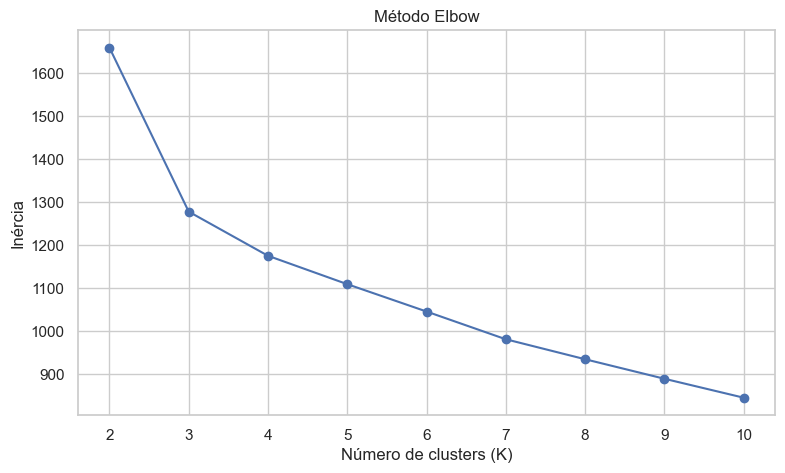

In [27]:
inertias = []
k_values = range(2, 11)

for k in k_values:
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    modelo.fit(X_scaled)
    inertias.append(modelo.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(list(k_values), inertias, marker="o")
plt.title("Método Elbow")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Inércia")
plt.xticks(list(k_values))
plt.show()


## 8. Silhouette Score

O Silhouette Score mede o quanto cada observação está próxima do seu próprio grupo em comparação com outros grupos. Valores maiores indicam maior separação/coerência dos agrupamentos.

Vamos calcular a silhueta para os mesmos valores de K e utilizar o resultado como evidência complementar ao método Elbow.

,K,Silhouette Score
0,2,0.259317
1,3,0.284859
2,4,0.260170
3,5,0.201619
4,6,0.237167
5,7,0.203628
6,8,0.157014
7,9,0.149882
8,10,0.143638


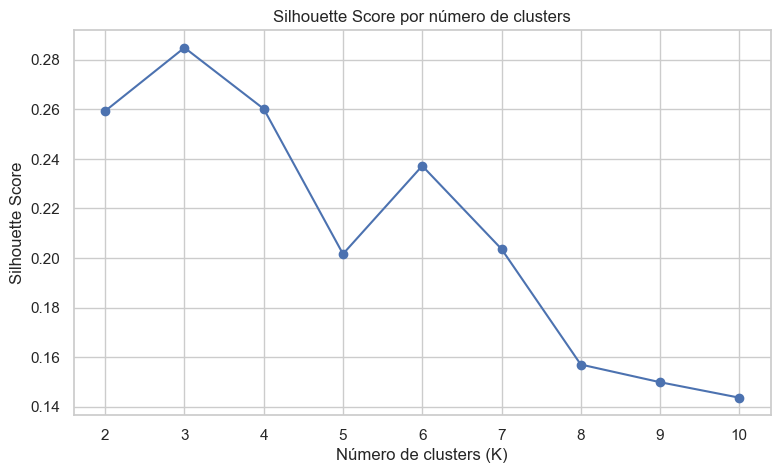

Maior Silhouette Score: K=3, score=0.2849


In [28]:
silhouette_values = []

for k in k_values:
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = modelo.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_values.append(score)

tabela_silhueta = pd.DataFrame({
    "K": list(k_values),
    "Silhouette Score": silhouette_values
})

display(tabela_silhueta)

plt.figure(figsize=(9, 5))
plt.plot(list(k_values), silhouette_values, marker="o")
plt.title("Silhouette Score por número de clusters")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(list(k_values))
plt.show()

# O maior Silhouette Score é mostrado abaixo para auxiliar na escolha.
k_silhueta = int(tabela_silhueta.loc[
    tabela_silhueta["Silhouette Score"].idxmax(), "K"
])
melhor_score_silhueta = tabela_silhueta["Silhouette Score"].max()

print(f"Maior Silhouette Score: K={k_silhueta}, score={melhor_score_silhueta:.4f}")


## 9. Escolha do número de clusters

O número final de grupos deve ser justificado observando **conjuntamente** o gráfico Elbow e o Silhouette Score.

In [29]:
# Sugestão automática baseada no maior Silhouette Score.
K_FINAL = k_silhueta

print(f"K escolhido inicialmente pelo Silhouette Score: {K_FINAL}")
print("Confira o gráfico Elbow para confirmar se esse valor também apresenta um ponto de cotovelo.")


K escolhido inicialmente pelo Silhouette Score: 3
Confira o gráfico Elbow para confirmar se esse valor também apresenta um ponto de cotovelo.


## 10. Ajuste final do K-means

Com o K definido, treinamos o modelo final e adicionamos o grupo de cada vinho ao dataset.

In [30]:
kmeans_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(X_scaled)

df_resultado = df_ml.copy()
df_resultado["Cluster"] = clusters + 1  # grupos apresentados como 1, 2, 3...

display(df_resultado.head())
print("\nQuantidade de vinhos por grupo:")
display(df_resultado["Cluster"].value_counts().sort_index())


,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline,Cluster
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,3
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,3
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,3
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,3
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,3



Quantidade de vinhos por grupo:


Cluster
1    65
2    51
3    62
Name: count, dtype: int64

## 11. Análise dos grupos

Para interpretar os clusters, calculamos a média de cada feature em cada grupo. Isso permite responder perguntas como:
- qual grupo apresenta maior teor alcoólico;
- qual grupo apresenta maior acidez;
- quais características diferenciam os grupos.

Como as features estão em escalas diferentes, a interpretação abaixo usa os valores **originais** do dataset.

In [31]:
# Médias das features originais por cluster
medias_clusters = df_resultado.groupby("Cluster")[X.columns].mean()

display(medias_clusters.round(3))


,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
Cluster,,,,,,,,,,,,,
1,12.251,1.897,2.231,20.063,92.738,2.248,2.050,0.358,1.624,2.973,1.063,2.803,510.169
2,13.134,3.307,2.418,21.241,98.667,1.684,0.819,0.452,1.146,7.235,0.692,1.697,619.059
3,13.677,1.998,2.466,17.463,107.968,2.848,3.003,0.292,1.922,5.454,1.065,3.163,1100.226


### Comparação visual dos grupos

O gráfico abaixo mostra as médias das principais variáveis para cada grupo. Ele ajuda a visualizar quais características aumentam ou diminuem de um cluster para outro.

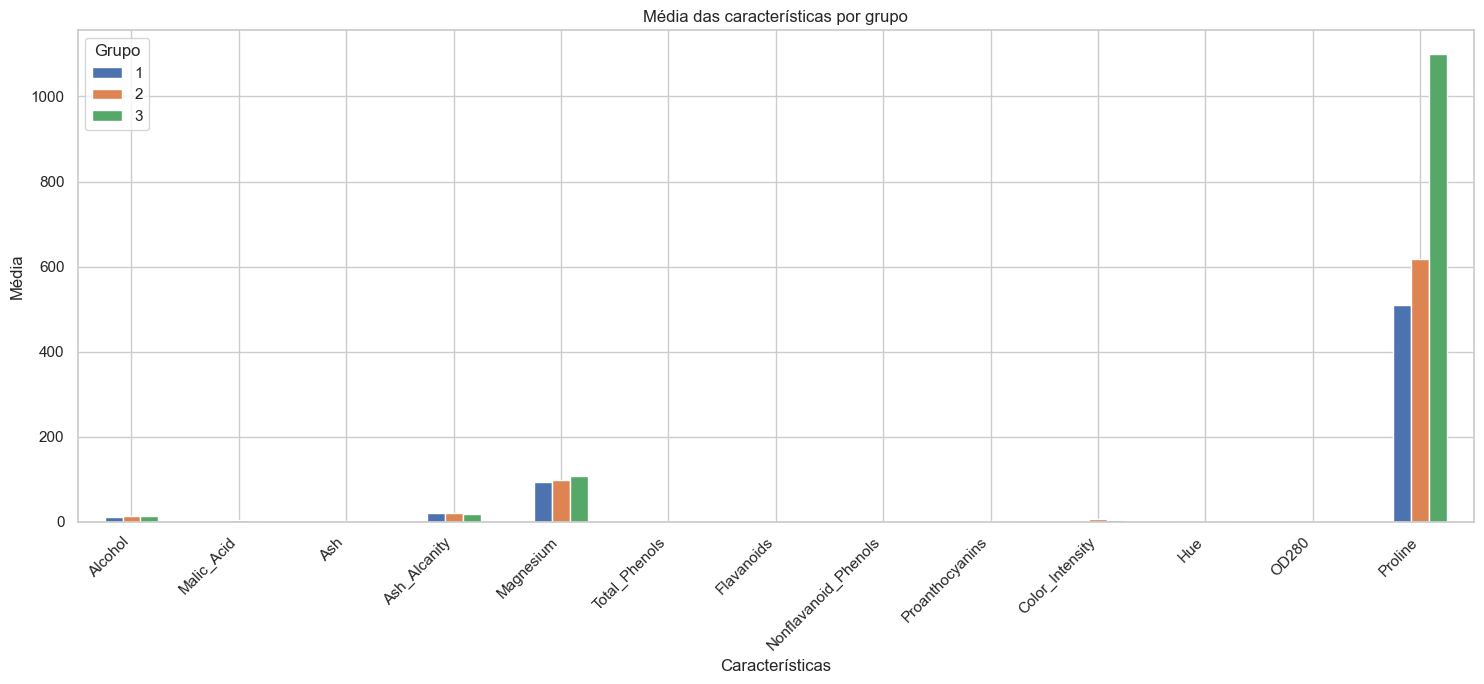

In [32]:
# Gráfico das médias por cluster para todas as features
medias_clusters.T.plot(kind="bar", figsize=(15, 7))
plt.title("Média das características por grupo")
plt.xlabel("Características")
plt.ylabel("Média")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Grupo")
plt.tight_layout()
plt.show()


## 12. Respostas automáticas para a interpretação

Abaixo, o notebook identifica objetivamente o grupo com maior média de teor alcoólico e o grupo com maior média de `Malic acid`. Os valores são derivados diretamente dos dados agrupados.

In [34]:
# Grupo com maior teor alcoólico
grupo_maior_alcohol = medias_clusters["Alcohol"].idxmax()
valor_maior_alcohol = medias_clusters["Alcohol"].max()

# Grupo com maior acidez málica
grupo_maior_malic = medias_clusters["Malic_Acid"].idxmax()
valor_maior_malic = medias_clusters["Malic_Acid"].max()

print(f"Grupo com maior teor alcoólico médio: Grupo {grupo_maior_alcohol} ({valor_maior_alcohol:.3f})")
print(f"Grupo com maior acidez málica média: Grupo {grupo_maior_malic} ({valor_maior_malic:.3f})")

# Ranking das características por grupo.
for grupo in medias_clusters.index:
    print(f"\nGrupo {grupo}:")
    serie = medias_clusters.loc[grupo].sort_values(ascending=False)
    print("Maiores médias:")
    display(serie.head(5).to_frame("Média"))
    print("Menores médias:")
    display(serie.tail(5).to_frame("Média"))


Grupo com maior teor alcoólico médio: Grupo 3 (13.677)
Grupo com maior acidez málica média: Grupo 2 (3.307)

Grupo 1:
Maiores médias:


,Média
Proline,510.169231
Magnesium,92.738462
Ash_Alcanity,20.063077
Alcohol,12.250923
Color_Intensity,2.973077


Menores médias:


,Média
Flavanoids,2.050000
Malic_Acid,1.897385
Proanthocyanins,1.624154
Hue,1.062708
Nonflavanoid_Phenols,0.357692



Grupo 2:
Maiores médias:


...

,Média
Total_Phenols,1.683922
Proanthocyanins,1.145882
Flavanoids,0.818824
Hue,0.691961
Nonflavanoid_Phenols,0.451961



Grupo 3:
Maiores médias:


,Média
Proline,1100.225806
Magnesium,107.967742
Ash_Alcanity,17.462903
Alcohol,13.676774
Color_Intensity,5.453548


Menores médias:


,Média
Ash,2.466290
Malic_Acid,1.997903
Proanthocyanins,1.922097
Hue,1.065484
Nonflavanoid_Phenols,0.292097


## 13. Visualização dos clusters

Para uma visualização simples em duas dimensões, serão utilizados `Alcohol` e `Malic acid`. As cores representam os grupos encontrados pelo K-means.

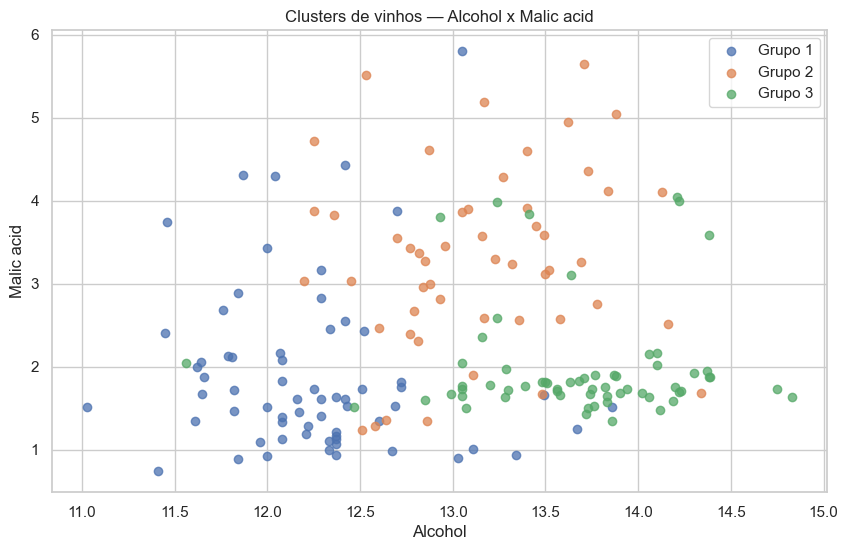

In [36]:
plt.figure(figsize=(10, 6))

for grupo in sorted(df_resultado["Cluster"].unique()):
    dados_grupo = df_resultado[df_resultado["Cluster"] == grupo]
    plt.scatter(
        dados_grupo["Alcohol"],
        dados_grupo["Malic_Acid"],
        label=f"Grupo {grupo}",
        alpha=0.75
    )

plt.title("Clusters de vinhos — Alcohol x Malic acid")
plt.xlabel("Alcohol")
plt.ylabel("Malic acid")
plt.legend()
plt.show()


# 14. Conclusão

**Statistical Computing**
- foram selecionadas duas variáveis quantitativas;
- foram construídas tabelas de distribuição de frequências e gráficos;
- foram calculadas medidas de tendência central, dispersão e quartis;
- foram realizadas duas análises probabilísticas para cada variável.

**Machine Learning & Modelling**
- os dados foram verificados e tratados;
- uma eventual feature de classe foi retirada do agrupamento;
- as features numéricas foram padronizadas;
- foi aplicado K-means;
- o número de clusters foi analisado pelos métodos Elbow e Silhouette;
- os grupos foram comparados pelas características médias dos vinhos.
